In [1]:
import os
import psutil

proc = psutil.Process(os.getpid())
vm = psutil.virtual_memory()

print("Process RAM (GB):", round(proc.memory_info().rss / 1024**3, 3))
print("System used (GB):", round(vm.used / 1024**3, 3))
print("System total (GB):", round(vm.total / 1024**3, 3))
print("System percent:", vm.percent)

Process RAM (GB): 0.074
System used (GB): 22.721
System total (GB): 31.605
System percent: 71.9


In [2]:
from pathlib import Path

ZIP_PATH = Path(r"D:\Big Data\airline.csv.shuffle.zip")
OUT_DIR = Path(r"D:\Big Data\outputs_pandas")

DISK_BENCH_GB = 2.0
CHUNK_ROWS = 10_000_000
NROWS = None
ENCODING = "latin-1"
CHECK_DUPLICATES = True

OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Zip   :", ZIP_PATH)
print("Output:", OUT_DIR)
print("Exists:", ZIP_PATH.exists())

Zip   : D:\Big Data\airline.csv.shuffle.zip
Output: D:\Big Data\outputs_pandas
Exists: True


In [3]:
import gc
import io
import time
import zipfile
from contextlib import contextmanager

import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

with zipfile.ZipFile(ZIP_PATH) as zf:
    INNER_NAME = [n for n in zf.namelist() if not n.endswith("/")][0]
    CSV_SIZE_BYTES = zf.getinfo(INNER_NAME).file_size
ZIP_SIZE_BYTES = ZIP_PATH.stat().st_size


def open_csv_stream():
    zf = zipfile.ZipFile(ZIP_PATH)
    return io.TextIOWrapper(zf.open(INNER_NAME), encoding=ENCODING, errors="strict")


STAGE_TIMES = {}


@contextmanager
def time_stage(name):
    gc.collect()
    box = {"rows": None}
    t0 = time.perf_counter()
    yield box
    wall = round(time.perf_counter() - t0, 3)
    STAGE_TIMES[name] = {"Rows Processed": box["rows"], "Wall Time (s)": wall}
    print(f"[{wall:9.3f}s] {name}")


MB = 1024 ** 2

USECOLS = [
    "Year", "Month", "DayofMonth", "DayOfWeek",
    "UniqueCarrier", "Origin", "Dest", "Distance",
    "DepDelay", "ArrDelay", "Cancelled", "Diverted", "CancellationCode",
    "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay",
]

CAT_COLS = ["UniqueCarrier", "Origin", "Dest", "CancellationCode"]

READ_DTYPES = {
    "Year": "float32", "Month": "float32", "DayofMonth": "float32", "DayOfWeek": "float32",
    "Distance": "float32", "DepDelay": "float32", "ArrDelay": "float32",
    "Cancelled": "float32", "Diverted": "float32",
    "CarrierDelay": "float32", "WeatherDelay": "float32", "NASDelay": "float32",
    "SecurityDelay": "float32", "LateAircraftDelay": "float32",
    "UniqueCarrier": "category", "Origin": "category", "Dest": "category",
    "CancellationCode": "category",
}

DELAY_CAUSES = ["CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"]
MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

print(f"{INNER_NAME}  {CSV_SIZE_BYTES / 1024**3:.2f} GB uncompressed, "
      f"{ZIP_SIZE_BYTES / 1024**3:.2f} GB compressed")

airline.csv.shuffle  11.20 GB uncompressed, 4.20 GB compressed


In [4]:
BLOCK = 8 * MB
limit_bytes = int(min(DISK_BENCH_GB * 1024 ** 3, ZIP_SIZE_BYTES))

with time_stage("0. Disk read benchmark (raw bytes)") as t:
    read_bytes = 0
    with open(ZIP_PATH, "rb", buffering=0) as fh:
        while read_bytes < limit_bytes:
            block = fh.read(min(BLOCK, limit_bytes - read_bytes))
            if not block:
                break
            read_bytes += len(block)

print(f"{read_bytes / 1024 ** 3:.2f} GB read")

[    0.838s] 0. Disk read benchmark (raw bytes)
2.00 GB read


In [5]:
reader_kwargs = dict(
    usecols=USECOLS,
    dtype=READ_DTYPES,
    na_values=["NA"],
    keep_default_na=True,
    encoding=ENCODING,
    engine="c",
    on_bad_lines="skip",
    chunksize=CHUNK_ROWS,
    nrows=NROWS,
)

with time_stage("1. Data loading (read_csv, chunked)") as t:
    chunks = []
    for chunk in pd.read_csv(open_csv_stream(), **reader_kwargs):
        chunks.append(chunk)

    for col in CAT_COLS:
        cats = pd.Index(sorted(set().union(*(set(c[col].cat.categories) for c in chunks))))
        shared = CategoricalDtype(categories=cats)
        for c in chunks:
            c[col] = c[col].astype(shared)

    raw = pd.concat(chunks, ignore_index=True, copy=False)
    del chunks
    gc.collect()
    t["rows"] = len(raw)

print(f"{len(raw):,} rows x {raw.shape[1]} columns")

[  229.198s] 1. Data loading (read_csv, chunked)
123,534,969 rows x 18 columns


In [6]:
with time_stage("2a. Data quality audit (pre-clean)") as t:
    audit = pd.DataFrame({
        "dtype": raw.dtypes.astype(str),
        "non_null": raw.notna().sum(),
        "missing": raw.isna().sum(),
    })
    audit["missing_%"] = (100 * audit["missing"] / len(raw)).round(3)
    t["rows"] = len(raw)

display(audit)

[   11.995s] 2a. Data quality audit (pre-clean)


,dtype,non_null,missing,missing_%
ArrDelay,float32,120947440,2587529,2.095
CancellationCode,category,734706,122800263,99.405
Cancelled,float32,123534969,0,0.000
CarrierDelay,float32,34205536,89329433,72.311
DayOfWeek,float32,123534969,0,0.000
DayofMonth,float32,123534969,0,0.000
DepDelay,float32,121232833,2302136,1.864
Dest,category,123534969,0,0.000
Distance,float32,123332969,202000,0.164
Diverted,float32,123534969,0,0.000


In [7]:
clean_log = []

with time_stage("2b. Cleaning (filter + downcast)") as t:
    n_before = len(raw)
    keep = np.ones(n_before, dtype=bool)

    def rule(name, condition):
        global keep
        before = int(keep.sum())
        keep &= np.asarray(condition)
        after = int(keep.sum())
        clean_log.append({
            "Rule": name,
            "Rows removed": before - after,
            "% of original": round(100 * (before - after) / n_before, 4),
            "Rows remaining": after,
        })

    rule("1. Valid Year",         raw["Year"].between(1987, 2030).fillna(False))
    rule("2. Valid Month (1-12)", raw["Month"].between(1, 12).fillna(False))
    rule("3. Not cancelled",      (raw["Cancelled"] == 0).fillna(False))
    rule("4. Not diverted",       (raw["Diverted"] == 0).fillna(False))
    rule("5. ArrDelay present",   raw["ArrDelay"].notna())
    rule("6. |delay| <= 1440 min",
         (raw["ArrDelay"].abs() <= 1440) & (raw["DepDelay"].abs().fillna(0) <= 1440))

    df = raw[keep]
    del keep, raw
    gc.collect()

    if CHECK_DUPLICATES:
        before = len(df)
        df = df[~df.duplicated()]
        clean_log.append({
            "Rule": "7. Drop exact duplicates",
            "Rows removed": before - len(df),
            "% of original": round(100 * (before - len(df)) / n_before, 4),
            "Rows remaining": len(df),
        })

    df["Year"] = df["Year"].astype("int16")
    df["Month"] = df["Month"].astype("int8")
    df["DayOfWeek"] = df["DayOfWeek"].astype("int8")
    df = df.drop(columns=["Cancelled", "Diverted"])
    for col in CAT_COLS:
        df[col] = df[col].cat.remove_unused_categories()

    df["Delayed15"] = (df["ArrDelay"] > 15)
    df = df.reset_index(drop=True)
    gc.collect()

    t["rows"] = len(df)

log_df = pd.DataFrame(clean_log)
display(log_df.set_index("Rule"))

[  290.810s] 2b. Cleaning (filter + downcast)


,Rows removed,% of original,Rows remaining
Rule,,,
1. Valid Year,0,0.000,123534969
2. Valid Month (1-12),0,0.000,123534969
3. Not cancelled,2303324,1.865,121231645
4. Not diverted,284204,0.230,120947441
5. ArrDelay present,1,0.000,120947440
6. |delay| <= 1440 min,83,0.000,120947357
7. Drop exact duplicates,2444026,1.978,118503331


In [8]:
with time_stage("3a. Schema description") as t:
    schema = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
    })
    schema["missing_%"] = (100 * schema["missing"] / len(df)).round(3)
    schema["n_unique"] = [
        df[c].cat.categories.size if str(df[c].dtype) == "category" else
        (df[c].nunique() if df[c].dtype.kind in "biu" else np.nan)
        for c in df.columns
    ]
    t["rows"] = len(df)

display(schema)

[    7.252s] 3a. Schema description


,dtype,non_null,missing,missing_%,n_unique
ArrDelay,float32,118503331,0,0.000,NaN
CancellationCode,category,10,118503321,100.000,3.000
CarrierDelay,float32,33063650,85439681,72.099,NaN
DayOfWeek,int8,118503331,0,0.000,7.000
DayofMonth,float32,118503331,0,0.000,NaN
DepDelay,float32,118503331,0,0.000,NaN
Dest,category,118503331,0,0.000,343.000
Distance,float32,118309103,194228,0.164,NaN
LateAircraftDelay,float32,33063650,85439681,72.099,NaN
Month,int8,118503331,0,0.000,12.000


In [9]:
with time_stage("3b. Summary statistics (describe)") as t:
    num_desc = df.select_dtypes(include=[np.number]).describe(
        percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]
    ).T
    t["rows"] = len(df)

display(num_desc)

[   53.371s] 3b. Summary statistics (describe)


,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
ArrDelay,"118,503,331.000",7.258,30.987,"-1,437.000",-27.000,-7.000,0.000,11.000,57.000,137.000,"1,438.000"
CarrierDelay,"33,063,650.000",3.807,20.086,0.000,0.000,0.000,0.000,0.000,22.000,83.000,"1,431.000"
DayOfWeek,"118,503,331.000",3.950,1.991,1.000,1.000,2.000,4.000,6.000,7.000,7.000,7.000
DayofMonth,"118,503,331.000",15.734,8.791,1.000,1.000,8.000,16.000,23.000,29.000,31.000,31.000
DepDelay,"118,503,331.000",8.283,28.518,"-1,410.000",-10.000,-2.000,0.000,7.000,52.000,129.000,"1,439.000"
Distance,"118,309,103.000",708.845,554.203,0.000,79.000,309.000,550.000,946.000,"1,851.000","2,553.000","4,983.000"
LateAircraftDelay,"33,063,650.000",4.920,20.539,0.000,0.000,0.000,0.000,0.000,33.000,104.000,"1,366.000"
Month,"118,503,331.000",6.564,3.439,1.000,1.000,4.000,7.000,10.000,12.000,12.000,12.000
NASDelay,"33,063,650.000",4.244,16.858,-60.000,0.000,0.000,0.000,0.000,25.000,79.000,"1,392.000"
SecurityDelay,"33,063,650.000",0.028,1.214,0.000,0.000,0.000,0.000,0.000,0.000,0.000,533.000


In [10]:
with time_stage("3c. Categorical description") as t:
    cat_desc = df[CAT_COLS].describe().T
    cat_desc["n_unique"] = [df[c].cat.categories.size for c in CAT_COLS]
    t["rows"] = len(df)

display(cat_desc)

[    2.179s] 3c. Categorical description


,count,unique,top,freq,n_unique
UniqueCarrier,118503331,29,DL,16073976,29
Origin,118503331,347,ORD,6331729,347
Dest,118503331,343,ORD,6355471,343
CancellationCode,10,3,A,6,3


In [11]:
BIN_W = 5
LO, HI = -60, 180

with time_stage("4. EDA 1 - delay distribution (histogram binning)") as t:
    arr = df["ArrDelay"].to_numpy(dtype="float32", copy=False)
    bins = np.arange(LO, HI + BIN_W, BIN_W, dtype="float32")
    counts, edges = np.histogram(arr, bins=bins)
    n_below = int((arr < LO).sum())
    n_above = int((arr > HI).sum())
    pct = np.percentile(arr, [1, 5, 25, 50, 75, 90, 95, 99, 99.9])
    mean_delay = float(arr.mean())
    t["rows"] = len(df)

pct_tbl = pd.DataFrame({"ArrDelay (min)": np.round(pct, 1)},
                       index=["1%", "5%", "25%", "50%", "75%", "90%", "95%", "99%", "99.9%"])
pct_tbl.index.name = "percentile"
display(pct_tbl)
print(f"Mean {mean_delay:.3f} min, median {pct[3]:.1f} min")
print(f"Outside [{LO}, {HI}]: {n_below:,} below, {n_above:,} above")

[    2.579s] 4. EDA 1 - delay distribution (histogram binning)


,ArrDelay (min)
percentile,
1%,-27.000
5%,-18.000
25%,-7.000
50%,0.000
75%,11.000
90%,32.000
95%,57.000
99%,137.000
99.9%,282.000


Mean 7.258 min, median 0.0 min
Outside [-60, 180]: 3,681 below, 553,029 above


In [12]:
MIN_FLIGHTS = max(1000, int(0.0005 * len(df)))

with time_stage("5. EDA 2 - airline comparison (groupby aggregation)") as t:
    by_carrier = (
        df.groupby("UniqueCarrier", observed=True)["ArrDelay"]
          .agg(flights="count", mean_delay="mean", median_delay="median")
    )
    by_carrier["pct_delayed_15"] = (
        df.groupby("UniqueCarrier", observed=True)["Delayed15"].mean() * 100
    )
    t["rows"] = len(df)

ranked = by_carrier[by_carrier["flights"] >= MIN_FLIGHTS].sort_values("mean_delay")
display(ranked.round(2))

[    6.742s] 5. EDA 2 - airline comparison (groupby aggregation)


,flights,mean_delay,median_delay,pct_delayed_15
UniqueCarrier,,,,
HA,258486,-0.560,-4.000,6.460
AQ,145318,1.310,-2.000,9.050
ML (1),64177,5.350,0.000,14.420
NW,9982197,5.540,-1.000,18.180
F9,333680,5.730,0.000,18.850
PA (1),294645,5.910,0.000,19.400
OO,2942603,6.110,-2.000,17.570
9E,503028,6.140,-4.000,18.770
TZ,205428,6.170,-3.000,19.050


In [13]:
with time_stage("6. EDA 3 - monthly trend (groupby aggregation)") as t:
    by_month = (
        df.groupby("Month", observed=True)["ArrDelay"]
          .agg(flights="count", mean_delay="mean", median_delay="median")
          .sort_index()
    )
    by_month["pct_delayed_15"] = (
        df.groupby("Month", observed=True)["Delayed15"].mean().sort_index() * 100
    )
    t["rows"] = len(df)

by_month.index = [MONTH_NAMES[int(i) - 1] for i in by_month.index]
display(by_month.round(2))

[    6.127s] 6. EDA 3 - monthly trend (groupby aggregation)


,flights,mean_delay,median_delay,pct_delayed_15
Jan,9718721,8.670,1.000,22.440
Feb,8974597,8.110,1.000,21.540
Mar,10007561,7.450,0.000,20.400
Apr,9725754,5.440,0.000,17.250
May,9966350,5.680,-1.000,17.280
Jun,9841218,9.950,1.000,22.120
Jul,10174710,9.080,0.000,20.900
Aug,10250222,7.970,0.000,20.040
Sep,9464386,3.580,-2.000,14.770
Oct,10378287,4.930,0.000,16.620


In [14]:
with time_stage("7. EDA 4 - delay cause breakdown") as t:
    cause_totals = {c: float(df.loc[df[c] > 0, c].sum()) for c in DELAY_CAUSES}
    t["rows"] = len(df)

total_minutes = sum(cause_totals.values()) or 1
cause_tbl = (
    pd.DataFrame({"Cause": list(cause_totals.keys()), "Minutes": list(cause_totals.values())})
    .assign(Pct=lambda d: 100 * d["Minutes"] / total_minutes)
    .sort_values("Minutes", ascending=False)
    .set_index("Cause")
)
display(cause_tbl.round(1))

[    0.935s] 7. EDA 4 - delay cause breakdown


,Minutes,Pct
Cause,,
LateAircraftDelay,"162,671,968.000",35.600
NASDelay,"140,309,056.000",30.700
CarrierDelay,"125,862,576.000",27.600
WeatherDelay,"26,962,598.000",5.900
SecurityDelay,"913,344.000",0.200


In [15]:
metrics = pd.DataFrame(
    [{"Stage": k, "Rows Processed": v["Rows Processed"], "Wall Time (s)": v["Wall Time (s)"]}
     for k, v in STAGE_TIMES.items()]
)
metrics.loc[len(metrics)] = {
    "Stage": "TOTAL",
    "Rows Processed": len(df),
    "Wall Time (s)": round(metrics["Wall Time (s)"].sum(), 3),
}

metrics.to_csv(OUT_DIR / "pandas_stage_times.csv", index=False)
display(metrics.set_index("Stage"))

,Rows Processed,Wall Time (s)
Stage,,
0. Disk read benchmark (raw bytes),NaN,0.838
"1. Data loading (read_csv, chunked)","123,534,969.000",229.198
2a. Data quality audit (pre-clean),"123,534,969.000",11.995
2b. Cleaning (filter + downcast),"118,503,331.000",290.810
3a. Schema description,"118,503,331.000",7.252
3b. Summary statistics (describe),"118,503,331.000",53.371
3c. Categorical description,"118,503,331.000",2.179
4. EDA 1 - delay distribution (histogram binning),"118,503,331.000",2.579
5. EDA 2 - airline comparison (groupby aggregation),"118,503,331.000",6.742


Graphs


In [16]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SURFACE   = "#fcfcfb"
INK       = "#0b0b0b"
INK_2     = "#52514e"
MUTED     = "#898781"
GRID      = "#e1e0d9"
BASELINE  = "#c3c2b7"

SERIES_1  = "#2a78d6"
SERIES_2  = "#eb6834"
SERIES_3  = "#1baf7a"
DIV_NEG   = "#2a78d6"
DIV_POS   = "#d03b3b"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.titlecolor": INK,
    "axes.titlepad": 14,
    "axes.labelsize": 10,
    "axes.labelcolor": INK_2,
    "axes.edgecolor": BASELINE,
    "axes.linewidth": 1.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "grid.alpha": 1.0,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelcolor": INK_2,
    "ytick.labelcolor": INK_2,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "text.color": INK,
    "legend.frameon": False,
    "figure.autolayout": False,
})


def finish(fig, ax, name, title, subtitle=None, source=None):
    ax.set_title(title, loc="left", pad=30 if subtitle else 14,
                 fontsize=13, fontweight="semibold", color=INK)
    if subtitle:
        ax.text(0, 1.015, subtitle, transform=ax.transAxes, fontsize=9.5,
                color=INK_2, va="bottom", ha="left")
    if source:
        fig.text(0.0, -0.02, source, fontsize=8, color=MUTED, ha="left", va="top", wrap=True)
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path)
    print(f"saved -> {path}")
    return path


THOUSANDS = FuncFormatter(lambda x, _pos=None: f"{x:,.0f}")
print("chart theme ready")

chart theme ready


saved -> D:\Big Data\outputs_pandas\figures\eda1_arrival_delay_distribution.png


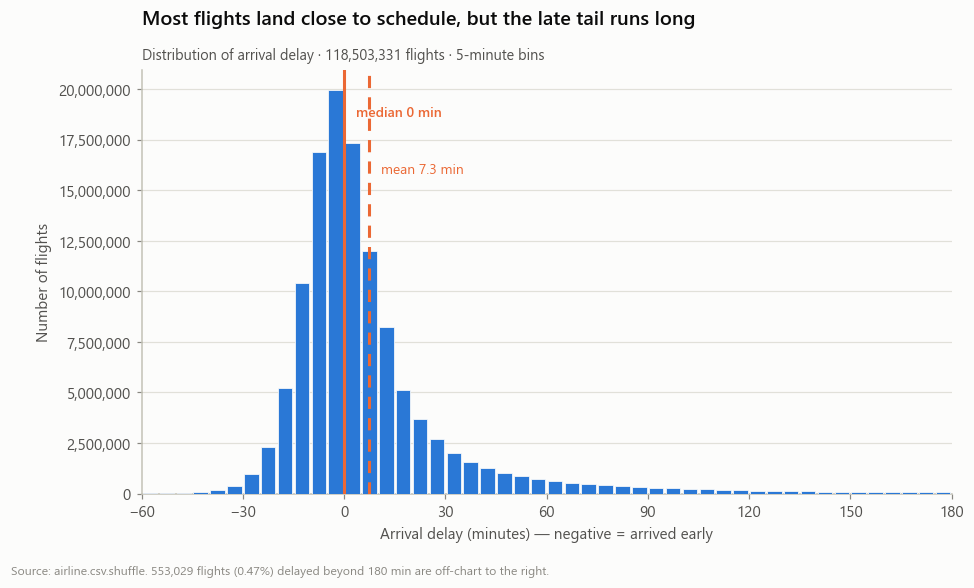

In [17]:
fig, ax = plt.subplots(figsize=(9.5, 5))
centres = edges[:-1] + BIN_W / 2
median = pct[3]

ax.bar(centres, counts, width=BIN_W * 0.86, color=SERIES_1,
       edgecolor=SURFACE, linewidth=0.5, zorder=3)
ax.axvline(0, color=BASELINE, linewidth=1.2, zorder=2)
ax.axvline(median, color=SERIES_2, linewidth=2, zorder=4)
ax.axvline(mean_delay, color=SERIES_2, linewidth=2, linestyle=(0, (4, 3)), zorder=4)

ymax = counts.max()
ax.annotate(f"median {median:,.0f} min", xy=(median, ymax * 0.96),
            xytext=(8, 0), textcoords="offset points",
            color=SERIES_2, fontsize=9, fontweight="semibold", va="top")
ax.annotate(f"mean {mean_delay:,.1f} min", xy=(mean_delay, ymax * 0.82),
            xytext=(8, 0), textcoords="offset points",
            color=SERIES_2, fontsize=9, va="top")

ax.set_xlim(LO, HI)
ax.set_xlabel("Arrival delay (minutes) — negative = arrived early")
ax.set_ylabel("Number of flights")
ax.yaxis.set_major_formatter(THOUSANDS)
ax.xaxis.set_major_locator(MultipleLocator(30))
ax.grid(axis="y", zorder=0)
ax.grid(axis="x", visible=False)

finish(fig, ax, "eda1_arrival_delay_distribution",
       title="Most flights land close to schedule, but the late tail runs long",
       subtitle=f"Distribution of arrival delay · {len(df):,} flights · {BIN_W}-minute bins",
       source=f"Source: airline.csv.shuffle. {n_above:,} flights "
              f"({n_above / len(arr):.2%}) delayed beyond {HI} min are off-chart to the right.")
plt.show()

saved -> D:\Big Data\outputs_pandas\figures\eda2_airline_comparison.png


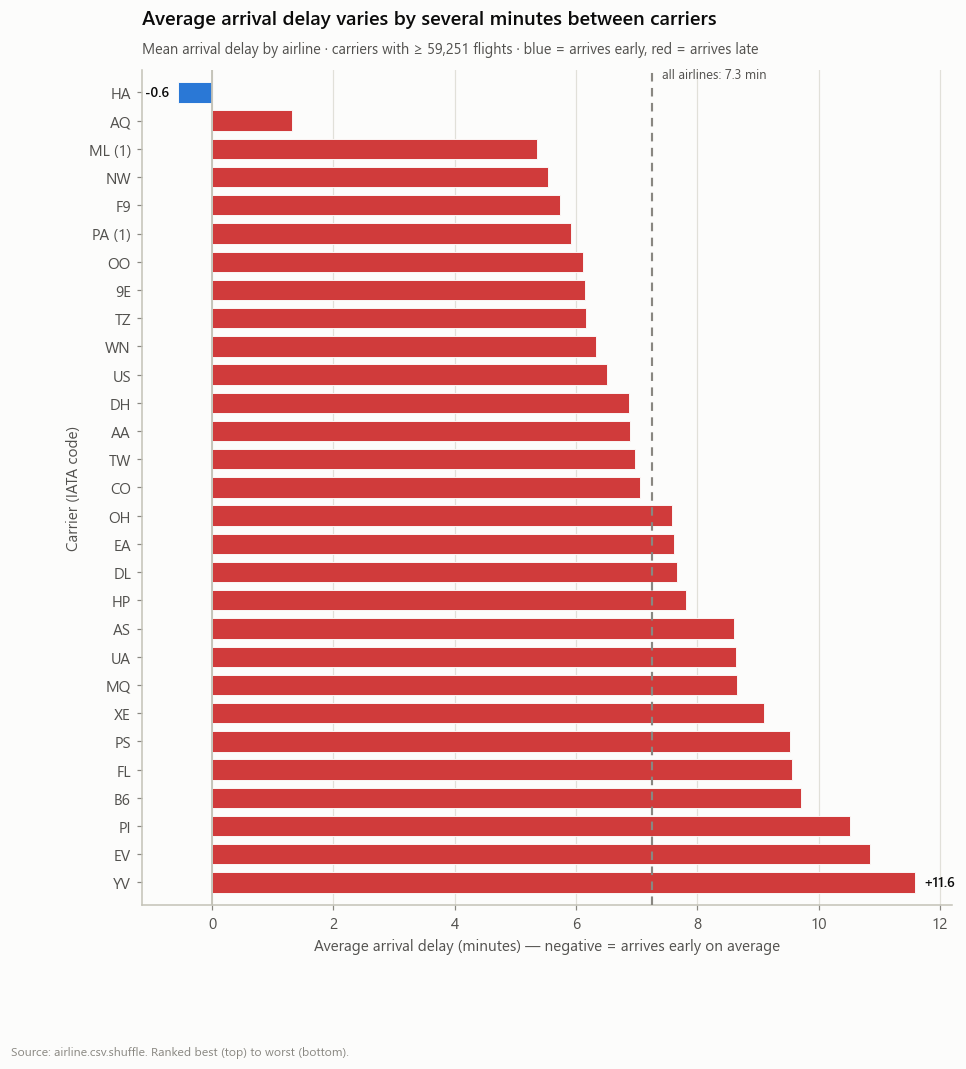

In [18]:
fig, ax = plt.subplots(figsize=(9.5, max(5, 0.34 * len(ranked))))

vals = ranked["mean_delay"].to_numpy()
labels = ranked.index.astype(str).tolist()
ypos = np.arange(len(vals))
colors = np.where(vals >= 0, DIV_POS, DIV_NEG)

ax.barh(ypos, vals, height=0.72, color=colors, edgecolor=SURFACE, linewidth=0.6, zorder=3)
ax.axvline(0, color=BASELINE, linewidth=1.2, zorder=4)
ax.axvline(mean_delay, color=MUTED, linewidth=1.4, linestyle=(0, (4, 3)), zorder=4)
ax.annotate(f"all airlines: {mean_delay:.1f} min", xy=(mean_delay, -0.62),
            xytext=(6, 0), textcoords="offset points",
            color=INK_2, fontsize=8.5, va="center")

for i in (0, len(vals) - 1):
    v = vals[i]
    ax.annotate(f"{v:+.1f}", xy=(v, ypos[i]),
                xytext=(6 if v >= 0 else -6, 0), textcoords="offset points",
                ha="left" if v >= 0 else "right", va="center",
                fontsize=9, fontweight="semibold", color=INK)

ax.set_yticks(ypos, labels)
ax.set_ylim(-0.8, len(vals) - 0.2)
ax.invert_yaxis()
ax.set_xlabel("Average arrival delay (minutes) — negative = arrives early on average")
ax.set_ylabel("Carrier (IATA code)")
ax.grid(axis="x", zorder=0)
ax.grid(axis="y", visible=False)

finish(fig, ax, "eda2_airline_comparison",
       title="Average arrival delay varies by several minutes between carriers",
       subtitle=f"Mean arrival delay by airline · carriers with ≥ {MIN_FLIGHTS:,} flights · "
                f"blue = arrives early, red = arrives late",
       source="Source: airline.csv.shuffle. Ranked best (top) to worst (bottom).")
plt.show()

saved -> D:\Big Data\outputs_pandas\figures\eda3_monthly_trend.png


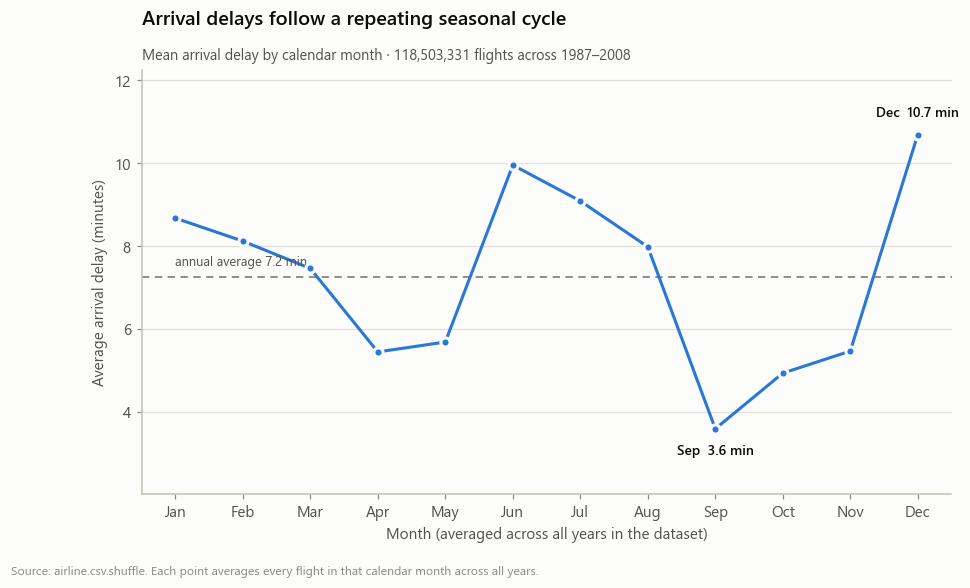

In [19]:
year_min, year_max = int(df["Year"].min()), int(df["Year"].max())

fig, ax = plt.subplots(figsize=(9.5, 5))
x = np.arange(len(by_month))
y = by_month["mean_delay"].to_numpy()

ax.plot(x, y, color=SERIES_1, linewidth=2, zorder=3, solid_capstyle="round")
ax.plot(x, y, "o", markersize=6, color=SERIES_1,
        markeredgecolor=SURFACE, markeredgewidth=2, zorder=4)

grand = float(y.mean())
ax.axhline(grand, color=MUTED, linewidth=1.2, linestyle=(0, (4, 3)), zorder=2)
ax.annotate(f"annual average {grand:.1f} min", xy=(0, grand),
            xytext=(0, 6), textcoords="offset points",
            ha="left", va="bottom", color=INK_2, fontsize=8.5)

hi, lo = int(np.argmax(y)), int(np.argmin(y))
for idx, va, dy in ((hi, "bottom", 10), (lo, "top", -10)):
    ax.annotate(f"{by_month.index[idx]}  {y[idx]:.1f} min",
                xy=(x[idx], y[idx]), xytext=(0, dy),
                textcoords="offset points", ha="center", va=va,
                fontsize=9, fontweight="semibold", color=INK)

ax.set_xticks(x, by_month.index.tolist())
ax.set_xlim(-0.5, len(x) - 0.5)
ax.margins(y=0.22)
ax.set_xlabel("Month (averaged across all years in the dataset)")
ax.set_ylabel("Average arrival delay (minutes)")
ax.grid(axis="y", zorder=0)
ax.grid(axis="x", visible=False)

finish(fig, ax, "eda3_monthly_trend",
       title="Arrival delays follow a repeating seasonal cycle",
       subtitle=f"Mean arrival delay by calendar month · {len(df):,} flights across "
                f"{year_min}–{year_max}",
       source="Source: airline.csv.shuffle. Each point averages every flight in that "
              "calendar month across all years.")
plt.show()

saved -> D:\Big Data\outputs_pandas\figures\eda4_delay_cause_breakdown.png


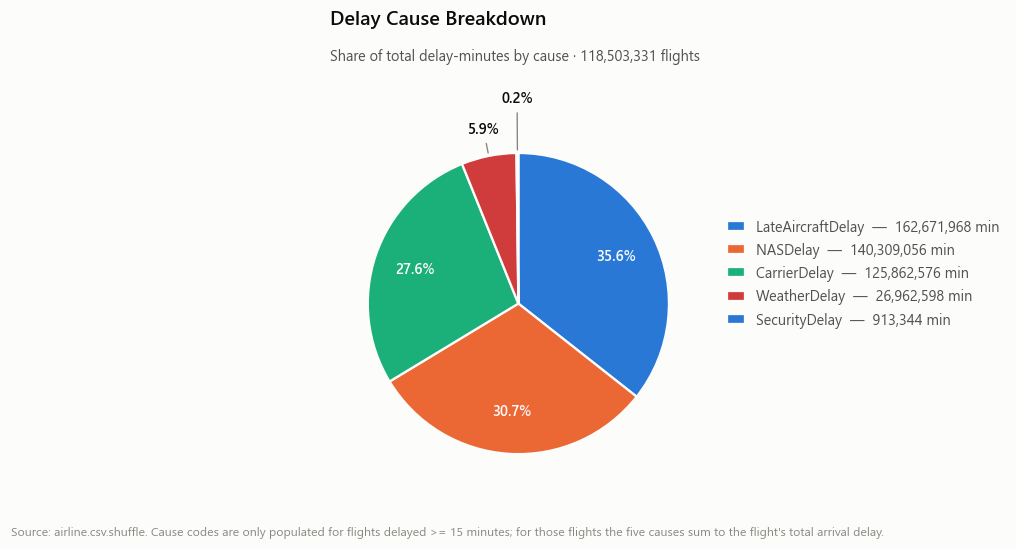

In [20]:
fig, ax = plt.subplots(figsize=(9, 5.6))
fig.subplots_adjust(top=0.72, bottom=0.06)

cause_ranked = cause_tbl.sort_values("Minutes", ascending=False)
colors = [SERIES_1, SERIES_2, SERIES_3, DIV_POS, DIV_NEG][:len(cause_ranked)]

wedges, _ = ax.pie(
    cause_ranked["Minutes"], colors=colors, startangle=90, counterclock=False,
    wedgeprops={"edgecolor": SURFACE, "linewidth": 1.5},
)

SMALL_PCT_THRESHOLD = 7.0
outside_radii = [1.18, 1.36]
k = 0
for wedge, p in zip(wedges, cause_ranked["Pct"]):
    angle = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
    cx, cy = np.cos(angle), np.sin(angle)
    if p < SMALL_PCT_THRESHOLD:
        r = outside_radii[k % len(outside_radii)]
        k += 1
        ax.annotate(f"{p:.1f}%", xy=(cx, cy), xytext=(cx * r, cy * r),
                    ha="center", va="center", fontsize=9.5, fontweight="semibold", color=INK,
                    arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.9))
    else:
        ax.annotate(f"{p:.1f}%", xy=(cx * 0.72, cy * 0.72),
                    ha="center", va="center", fontsize=9.5, fontweight="semibold", color=SURFACE)

ax.set_ylim(-1.15, 1.55)
labels = [f"{c}  —  {m:,.0f} min" for c, m in zip(cause_ranked.index, cause_ranked["Minutes"])]
ax.legend(wedges, labels, loc="center left", bbox_to_anchor=(1.02, 0.5),
          frameon=False, fontsize=9.5, labelcolor=INK_2, handlelength=1.2)
ax.set_aspect("equal")

finish(fig, ax, "eda4_delay_cause_breakdown",
       title="Delay Cause Breakdown",
       subtitle=f"Share of total delay-minutes by cause · {len(df):,} flights",
       source="Source: airline.csv.shuffle. Cause codes are only populated for flights "
              "delayed >= 15 minutes; for those flights the five causes sum to the "
              "flight's total arrival delay.")
plt.show()